## O que é o IDHM ##

Links importantes<br/>
https://www.undp.org/pt/brazil/o-que-%C3%A9-o-idhm<br/>
Base de dados Ipea<br/>
https://www.ipea.gov.br/ipeageo/arquivos/bases/IDH_2010.xls

O Índice de Desenvolvimento Humano Municipal (IDHM) é uma medida composta de indicadores de três dimensões do desenvolvimento humano: longevidade, educação e renda. O índice varia de 0 a 1. Quanto mais próximo de 1, maior o desenvolvimento humano.

O IDHM brasileiro segue as mesmas três dimensões do IDH Global - longevidade, educação e renda, mas vai além: adequa a metodologia global ao contexto brasileiro e à disponibilidade de indicadores nacionais. Embora meçam os mesmos fenômenos, os indicadores levados em conta no IDHM são mais adequados para avaliar o desenvolvimento dos municípios brasileiros. Assim, o IDHM - incluindo seus três componentes, IDHM Longevidade, IDHM Educação e IDHM Renda - conta um pouco da história dos municípios em três importantes dimensões do desenvolvimento humano durantes duas décadas da história brasileira.

Pergunta Norteadora: "Quais são os Estados que possuem um bom IDH para que possamos entregar bons produtos."

## Requirements: ##
ipykernel plotly pandas numpy matplotlib seaborn xlrd

In [1]:
# imports libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ler a base da de dado IDH
df = pd.read_excel("IDH_2010.xls")

In [3]:
df.head()

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,Esperança de vida ao nascer,Taxa de fecundidade total,Mortalidade infantil,Mortalidade até 5 anos de idade,Razão de dependência,...,População de 15 a 17 anos.1,População de 18 anos ou mais.1,População total em domicílios particulares permanentes,"População total em domicílios particulares permanentes, exceto com renda nula",Subíndice de escolaridade - IDHM Educação,Subíndice de frequência escolar - IDHM Educação,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,70.75,2.24,23.8,25.49,47.37,...,1602,16431,24097,22429,0.368,0.629,0.641,0.526,0.763,0.657
1,2010,11,Rondônia,110002,ARIQUEMES,73.36,1.91,19.2,20.53,46.68,...,5256,60213,89766,88730,0.514,0.648,0.702,0.600,0.806,0.716
2,2010,11,Rondônia,110003,CABIXI,70.39,2.15,24.8,26.58,48.12,...,381,4306,6303,6156,0.357,0.700,0.650,0.559,0.757,0.650
3,2010,11,Rondônia,110004,CACOAL,74.27,1.90,14.3,15.38,43.79,...,4547,54356,78141,76876,0.488,0.698,0.718,0.620,0.821,0.727
4,2010,11,Rondônia,110005,CEREJEIRAS,72.94,2.12,18.1,19.42,45.67,...,1033,11786,16942,16815,0.430,0.712,0.692,0.602,0.799,0.688


In [4]:
df_length = df.shape
print(f'Linhas: {df_length[0]} \n Colunas: {df_length[1]}')

Linhas: 5564 
 Colunas: 237


In [5]:
df.dtypes

ANO                                                  int64
Código da Unidade da Federação                       int64
Nome da Unidade da Federação                           str
Código do Município                                  int64
Município                                              str
                                                    ...   
Subíndice de frequência escolar - IDHM Educação    float64
IDHM                                               float64
IDHM Educação                                      float64
IDHM Longevidade                                   float64
IDHM Renda                                         float64
Length: 237, dtype: object

## Análise exploratória de dados ##

### Procura valores nulos ###

In [6]:
df.isnull().sum()

ANO                                                0
Código da Unidade da Federação                     0
Nome da Unidade da Federação                       0
Código do Município                                0
Município                                          0
                                                  ..
Subíndice de frequência escolar - IDHM Educação    0
IDHM                                               0
IDHM Educação                                      0
IDHM Longevidade                                   0
IDHM Renda                                         0
Length: 237, dtype: int64

In [7]:
df_qtd_null = df.isnull().sum().sum()
print(f'Dados Nulos: {df_qtd_null}')

Dados Nulos: 0


### Selecionando as informações necessárias ###

In [8]:
df.columns

Index(['ANO', 'Código da Unidade da Federação', 'Nome da Unidade da Federação',
       'Código do Município', 'Município', 'Esperança de vida ao nascer',
       'Taxa de fecundidade total', 'Mortalidade infantil',
       'Mortalidade até 5 anos de idade', 'Razão de dependência',
       ...
       'População de 15 a 17 anos.1', 'População de 18 anos ou mais.1',
       'População total em domicílios particulares permanentes',
       'População total em domicílios particulares permanentes, exceto com renda nula',
       'Subíndice de escolaridade - IDHM Educação',
       'Subíndice de frequência escolar - IDHM Educação', 'IDHM',
       'IDHM Educação', 'IDHM Longevidade', 'IDHM Renda'],
      dtype='str', length=237)

In [9]:
df = df[['Nome da Unidade da Federação', 'Município', 'IDHM', 'IDHM Educação', 'IDHM Longevidade', 'IDHM Renda']]

In [10]:
df.columns = ['uf', 'municipio', 'idhm', 'idhm_educacao', 'idhm_longevidade', 'idhm_renda']

In [11]:
df.nunique()

uf                    27
municipio           5329
idhm                 349
idhm_educacao        466
idhm_longevidade     220
idhm_renda           390
dtype: int64

### Estatística descritiva ###

**Classificação do IDHM:**
- 0 - 0,499 - Baixo;
- 0,5 - 0,7999 - Médio;
- 0,8 - 1 - Alto.

In [12]:
df.describe().round(2)

,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,5564.00,5564.00,5564.00,5564.00
mean,0.66,0.56,0.80,0.64
std,0.07,0.09,0.04,0.08
min,0.42,0.21,0.67,0.40
25%,0.60,0.49,0.77,0.57
50%,0.66,0.56,0.81,0.65
75%,0.72,0.63,0.84,0.71
max,0.86,0.82,0.89,0.89


In [13]:
def idhm_classif(df):
    if df['idhm'] <= 0.499:
        return 'Baixo'
    elif df['idhm'] >= 0.8:
        return 'Alto'
    else:
        return 'Médio'

In [14]:
dfbkp = df

In [15]:
df['idhm_classif'] = df.apply(idhm_classif, axis=1)

In [16]:
df.head(20)

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda,idhm_classif
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657,Médio
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716,Médio
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650,Médio
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727,Médio
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688,Médio
5,Rondônia,COLORADO DO OESTE,0.685,0.584,0.814,0.676,Médio
6,Rondônia,CORUMBIARA,0.613,0.473,0.774,0.630,Médio
7,Rondônia,COSTA MARQUES,0.611,0.493,0.751,0.616,Médio
8,Rondônia,ESPIGÃO D'OESTE,0.672,0.536,0.819,0.691,Médio
9,Rondônia,GUAJARÁ-MIRIM,0.657,0.519,0.823,0.663,Médio


In [17]:
df['idhm_classif'].value_counts()

idhm_classif
Médio    5488
Alto       44
Baixo      32
Name: count, dtype: int64

### Pairplot ###

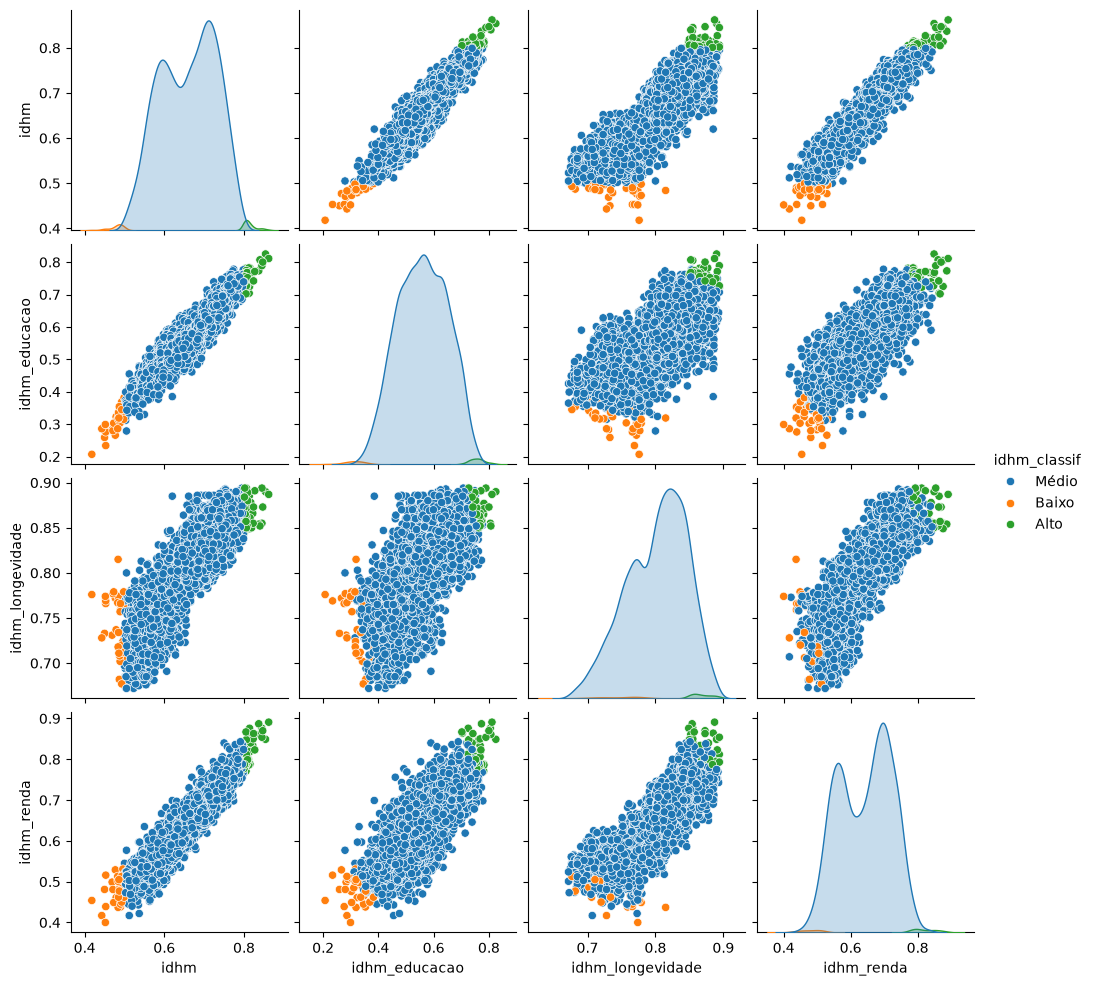

In [18]:
sns.pairplot(df, hue='idhm_classif')

Existe relação entre a Renda e Educação. Quanto maior a educação, maior a renda.

### Análise por Estado ###

In [19]:
#df_uf = pd.DataFrame(df.groupby('uf')['idhm'].mean().round(2)).reset_index()

df_uf = (
    df.groupby('uf')
      .agg(
          idhm_media=('idhm', 'mean'),
          educacao_media=('idhm_educacao', 'mean'),
          renda_media=('idhm_renda', 'mean'),
          longevidade_media=('idhm_longevidade', 'mean')
      )
      .round(2)
      .reset_index()
)

In [20]:
df_uf.columns = ['uf', 'idhm', 'idhm_educacao', 'idhm_renda', 'idhm_lonjevidade']
df_uf

,uf,idhm,idhm_educacao,idhm_renda,idhm_lonjevidade
0,Acre,0.59,0.45,0.59,0.77
1,Alagoas,0.56,0.44,0.55,0.74
2,Amapá,0.64,0.55,0.62,0.78
3,Amazonas,0.57,0.44,0.55,0.77
4,Bahia,0.59,0.48,0.57,0.76
5,Ceará,0.62,0.55,0.56,0.76
6,Distrito Federal,0.82,0.74,0.86,0.87
7,Espírito Santo,0.69,0.59,0.68,0.83
8,Goiás,0.69,0.60,0.68,0.83
9,Maranhão,0.58,0.49,0.53,0.74


In [21]:
df_uf['idhm_classif'] = df_uf.apply(idhm_classif, axis=1)

In [22]:
df_uf

,uf,idhm,idhm_educacao,idhm_renda,idhm_lonjevidade,idhm_classif
0,Acre,0.59,0.45,0.59,0.77,Médio
1,Alagoas,0.56,0.44,0.55,0.74,Médio
2,Amapá,0.64,0.55,0.62,0.78,Médio
3,Amazonas,0.57,0.44,0.55,0.77,Médio
4,Bahia,0.59,0.48,0.57,0.76,Médio
5,Ceará,0.62,0.55,0.56,0.76,Médio
6,Distrito Federal,0.82,0.74,0.86,0.87,Alto
7,Espírito Santo,0.69,0.59,0.68,0.83,Médio
8,Goiás,0.69,0.60,0.68,0.83,Médio
9,Maranhão,0.58,0.49,0.53,0.74,Médio


In [23]:
df_uf['idhm_classif'].value_counts()

idhm_classif
Médio    26
Alto      1
Name: count, dtype: int64

In [24]:
df_uf.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uf                27 non-null     str    
 1   idhm              27 non-null     float64
 2   idhm_educacao     27 non-null     float64
 3   idhm_renda        27 non-null     float64
 4   idhm_lonjevidade  27 non-null     float64
 5   idhm_classif      27 non-null     str    
dtypes: float64(4), str(2)
memory usage: 1.4 KB


In [25]:
df_uf.describe().round(2)

,idhm,idhm_educacao,idhm_renda,idhm_lonjevidade
count,27.00,27.00,27.00,27.00
mean,0.64,0.54,0.63,0.79
std,0.06,0.08,0.08,0.04
min,0.56,0.44,0.53,0.74
25%,0.59,0.48,0.57,0.76
50%,0.64,0.55,0.61,0.79
75%,0.69,0.60,0.68,0.82
max,0.82,0.74,0.86,0.87


Text(0, 0.5, 'Valores')

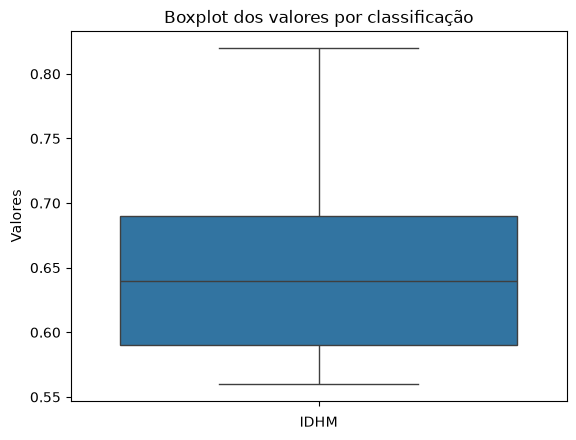

In [26]:
# usando o seaborn para grafico boxplot
sns.boxplot(y = df_uf['idhm'], data = df)

#add titulo e rotulo p/ eixos
plt.title('Boxplot dos valores por classificação')
plt.xlabel('IDHM')
plt.ylabel('Valores')

#retirar array de dados
#plt.show()

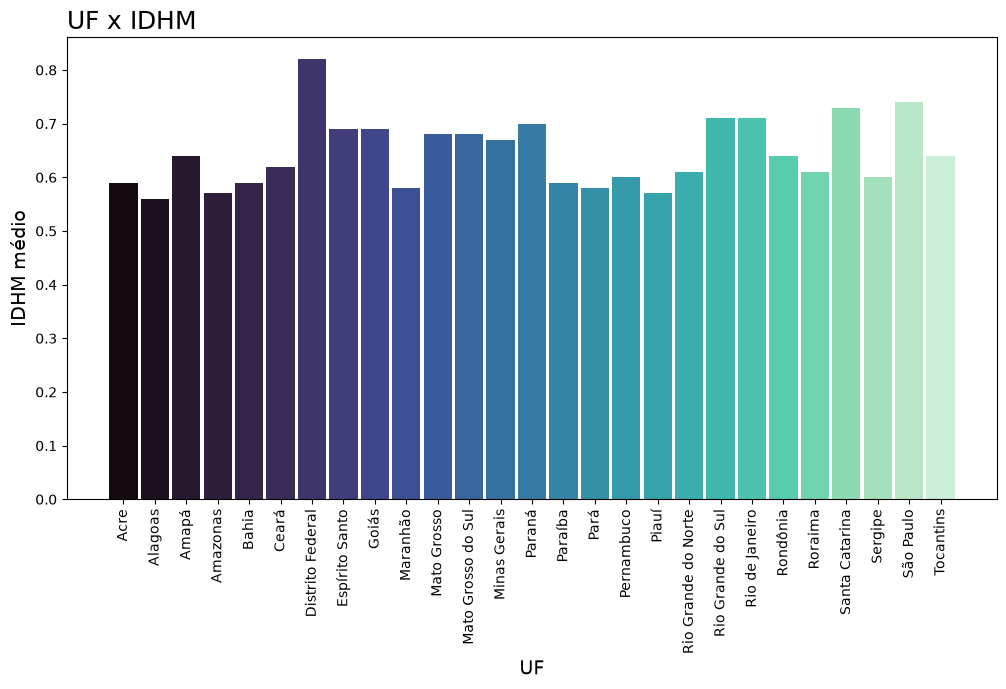

In [27]:
#grafico de barras:
plt.figure(figsize=(12, 6))

paleta_cores = sns.color_palette('mako', len(df_uf))

plt.bar(
        df_uf['uf'],
        df_uf['idhm'],
        width=0.9,
        color= paleta_cores
        )

plt.title('UF x IDHM', loc = 'left', fontsize=18)
plt.xlabel('UF', fontsize=14)
plt.ylabel('IDHM médio', fontsize=14)

plt.xticks(rotation=90)

plt.show()



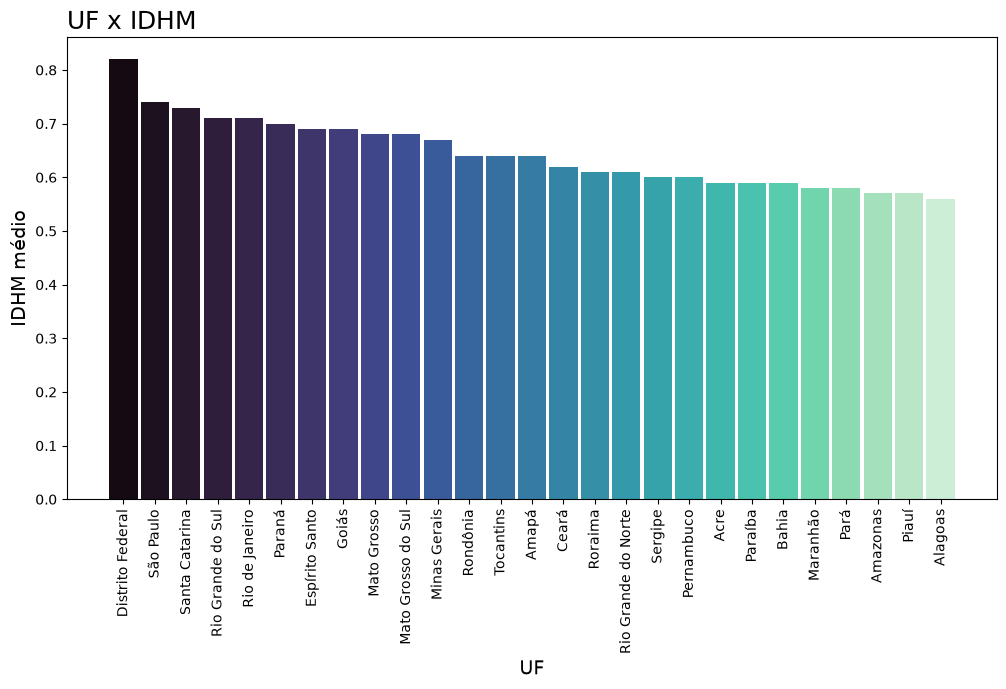

In [28]:
#ordenando o dataset
df_uf = df_uf.sort_values(by='idhm', ascending=False)

#grafico de barras:
plt.figure(figsize=(12, 6))

paleta_cores = sns.color_palette('mako', len(df_uf))

plt.bar(
        df_uf['uf'],
        df_uf['idhm'],
        width=0.9,
        color= paleta_cores
        )

plt.title('UF x IDHM', loc = 'left', fontsize=18)
plt.xlabel('UF', fontsize=14)
plt.ylabel('IDHM médio', fontsize=14)

plt.xticks(rotation=90)

plt.show()

In [30]:
# grafico usando o plotly
fig = px.bar(df_uf,
            x='uf',
            y='idhm',
            color='idhm_classif',
            title='IDHM médio por Estado',
            color_discrete_sequence=['green', 'orange']
            )

fig.show()

In [32]:
# potly com treemap
fig = px.treemap(df_uf,
            path=['uf'],
            values='idhm',
            title='IDHM médio por Estado'
            )

fig.show()